# 05 -- Park-Aware Model Analysis (Contact Luck v0.3)

**Contact Luck Prototype v0.3**

Does adding the venue as a categorical feature (`venue_id`) improve out-of-sample probability quality over the Version 0.2 `unweighted` baseline?

Two controlled variants, same 2021-2023 training rows, same untouched 2024 validation rows (2025 never touched):

- `baseline_v02` -- the currently-selected model (no venue feature).
- `park_aware_v03_candidate` -- the EXACT same model and features, plus `venue_id`.

**Adoption rule: this notebook does NOT automatically prefer the park-aware variant.** Recommending it requires improved probability quality (log loss and ECE) on 2024 AND no material venue-specific calibration failure -- see the recommendation section near the end, which is a starting point for judgment, not a substitute for reading the by-venue table yourself.

Does NOT yet include published park factors (e.g. altitude/wall-height adjustments) -- only the venue's bare categorical identity.

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.

In [1]:
import numpy as np
import pandas as pd

from mlb_luck_score.config import PROCESSED_DATA_DIR, RAW_DATA_DIR, TRAIN_SEASONS, VALIDATION_SEASONS
from mlb_luck_score.data.join_venue_metadata import build_venue_join_report, join_venue_metadata, load_game_metadata
from mlb_luck_score.models.compare_park_aware import (
    VARIANT_BASELINE_V02,
    VARIANT_PARK_AWARE_V03_CANDIDATE,
    recommend_park_aware_adoption,
    run_park_aware_comparison,
)
from mlb_luck_score.models.train_contact_model import predict_proba_ordered, train_model

JOINED_PATH = PROCESSED_DATA_DIR / "cleaned_development_data_with_venue.parquet"
CLEANED_PATH = PROCESSED_DATA_DIR / "cleaned_development_data.parquet"
pd.set_option("display.width", 160)

## Load venue-joined data

Prefers the already-joined file (from `make join-venue-metadata`). Falls back to joining on the fly from the plain cleaned dataset + cached game-metadata files if needed.

In [2]:
if JOINED_PATH.exists():
    df = pd.read_parquet(JOINED_PATH)
    print(f"Loaded pre-joined data: {len(df)} rows from {JOINED_PATH}")
elif CLEANED_PATH.exists():
    cleaned_df = pd.read_parquet(CLEANED_PATH)
    metadata_df = load_game_metadata(RAW_DATA_DIR, list(TRAIN_SEASONS) + list(VALIDATION_SEASONS))
    df = join_venue_metadata(cleaned_df, metadata_df)
    print(f"Joined on the fly: {len(df)} rows")
else:
    df = None
    metadata_df = None
    print(
        "No cleaned development data found. Run `make download-development-data && "
        "make clean-development-data` first, then `make download-game-metadata && "
        "make join-venue-metadata`, then re-run this notebook."
    )

Loaded pre-joined data: 494173 rows from /Users/arihantaneja/Downloads/TrueLuckMLBStat/data/processed/cleaned_development_data_with_venue.parquet


## Venue coverage report

In [3]:
if df is not None:
    if 'metadata_df' not in dir():
        metadata_df = load_game_metadata(RAW_DATA_DIR, list(TRAIN_SEASONS) + list(VALIDATION_SEASONS))
    report = build_venue_join_report(df, metadata_df)
    print(f"Total games:          {report.total_games}")
    print(f"Total event rows:     {report.total_event_rows}")
    print(f"Venue match rate:     {report.venue_match_rate:.4%}")
    print(f"Matched rows:         {report.matched_rows}")
    print(f"Unmatched rows:       {report.unmatched_rows}")
    print(f"Unmatched games:      {report.unmatched_games}")
    print(f"Duplicate mappings:   {report.duplicate_mappings}")
else:
    report = None
    print("Skipped -- no data loaded.")

Total games:          9714
Total event rows:     494173
Venue match rate:     99.9824%
Matched rows:         494086
Unmatched rows:       87
Unmatched games:      2
Duplicate mappings:   0


## Counts by park

,event_rows
venue_name,
Coors Field,17754
Kauffman Stadium,17404
Chase Field,17194
Nationals Park,17189
Fenway Park,16998
Busch Stadium,16931
Oriole Park at Camden Yards,16877
PNC Park,16803
Globe Life Field,16628


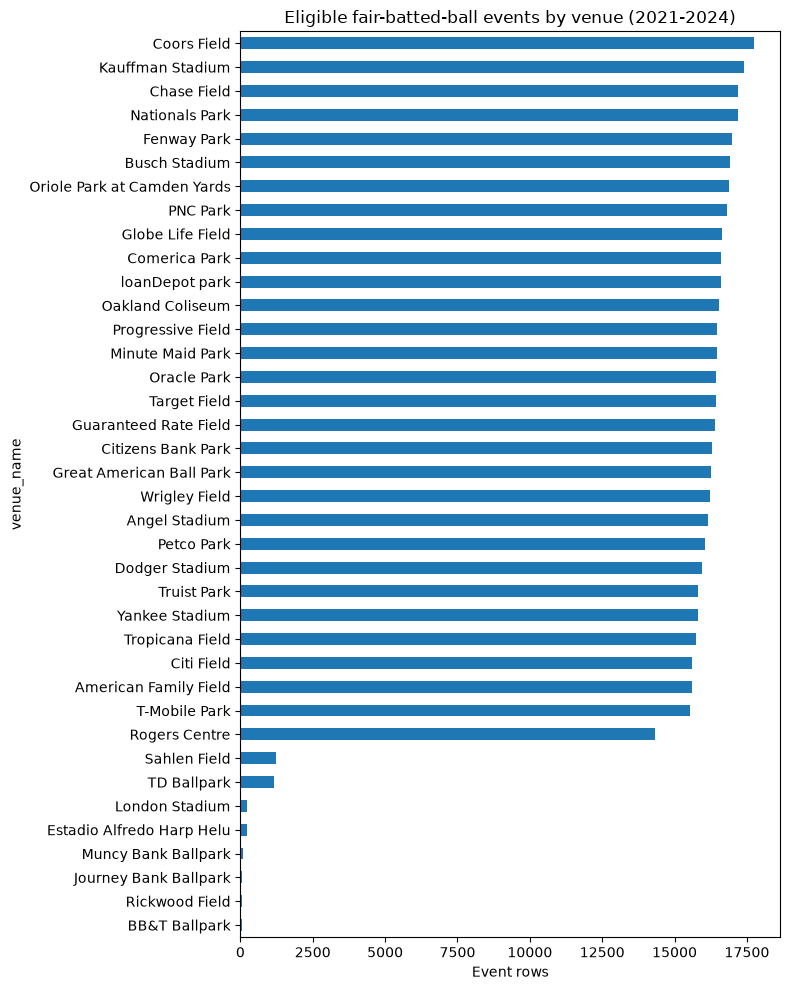

In [4]:
if df is not None:
    venue_counts = df["venue_name"].value_counts(dropna=True)
    display(venue_counts.to_frame("event_rows"))

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 10))
    venue_counts.sort_values().plot(kind="barh", ax=ax)
    ax.set_xlabel("Event rows")
    ax.set_title("Eligible fair-batted-ball events by venue (2021-2024)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- no data loaded.")

## Baseline (v0.2) vs. park-aware (v0.3 candidate)

Trains both variants on 2021-2023 and evaluates on untouched 2024 validation data.

In [5]:
if df is not None:
    comparison = run_park_aware_comparison(df)
    summary_rows = []
    for variant in (VARIANT_BASELINE_V02, VARIANT_PARK_AWARE_V03_CANDIDATE):
        s = comparison[variant]
        summary_rows.append(
            {
                "variant": variant,
                "multiclass_log_loss": s["multiclass_log_loss"],
                "expected_calibration_error": s["expected_calibration_error"],
                "home_run_ece": s["home_run_ece"],
                "argmax_accuracy (secondary)": s["argmax_accuracy_secondary"],
                "fly_ball_log_loss": s["fly_ball_subgroup"]["log_loss"],
                "fly_ball_ece": s["fly_ball_subgroup"]["ece"],
                "high_distance_log_loss": s["high_distance_subgroup"]["log_loss"],
                "high_distance_ece": s["high_distance_subgroup"]["ece"],
            }
        )
    display(pd.DataFrame(summary_rows).set_index("variant"))
    print(
        "\nLog loss and ECE: LOWER is better (probability quality). Accuracy is "
        "reported only as a SECONDARY number -- see mlb_luck_score.models.compare_models "
        "for why classification accuracy must never be conflated with calibration."
    )
else:
    comparison = None
    print("Skipped -- no data loaded.")

6 of 41 calibration bin(s) have fewer than 20 samples and are marked unreliable.


3 of 36 calibration bin(s) have fewer than 20 samples and are marked unreliable.


3 of 35 calibration bin(s) have fewer than 20 samples and are marked unreliable.


3 of 36 calibration bin(s) have fewer than 20 samples and are marked unreliable.


2 of 35 calibration bin(s) have fewer than 20 samples and are marked unreliable.


...

4 of 35 calibration bin(s) have fewer than 20 samples and are marked unreliable.


6 of 31 calibration bin(s) have fewer than 20 samples and are marked unreliable.


5 of 38 calibration bin(s) have fewer than 20 samples and are marked unreliable.


,multiclass_log_loss,expected_calibration_error,home_run_ece,argmax_accuracy (secondary),fly_ball_log_loss,fly_ball_ece,high_distance_log_loss,high_distance_ece
variant,,,,,,,,
baseline_v02,0.670321,0.014413,0.002706,0.751457,0.540974,0.018661,0.726446,0.048591
park_aware_v03_candidate,0.668930,0.014167,0.002977,0.750876,0.536920,0.019403,0.720030,0.048540



Log loss and ECE: LOWER is better (probability quality). Accuracy is reported only as a SECONDARY number -- see mlb_luck_score.models.compare_models for why classification accuracy must never be conflated with calibration.


## Calibration by park

Per-venue overall ECE for each variant, sorted by how much the park-aware model changed it (most-improved first). Only venues with `reliable=True` (at least `min_venue_samples`, default 100) in the baseline are trustworthy signal -- small parks (neutral-site one-offs) will show noisy numbers.

In [6]:
if comparison is not None:
    base_venue = pd.DataFrame(comparison[VARIANT_BASELINE_V02]["calibration_by_venue"])
    cand_venue = pd.DataFrame(comparison[VARIANT_PARK_AWARE_V03_CANDIDATE]["calibration_by_venue"])
    by_venue = base_venue.merge(cand_venue, on="venue_id", suffixes=("_baseline", "_park_aware"))
    by_venue["ece_delta"] = by_venue["ece_overall_park_aware"] - by_venue["ece_overall_baseline"]
    by_venue = by_venue.sort_values("ece_delta")
    display(
        by_venue[
            [
                "venue_id",
                "sample_count_baseline",
                "ece_overall_baseline",
                "ece_overall_park_aware",
                "ece_delta",
                "reliable_baseline",
            ]
        ]
    )
    print(
        "\nNegative ece_delta = park-aware improved calibration at that venue; "
        "positive = it got worse. Inspect the largest positive deltas by hand -- "
        "the automated 'material regression' check in compare_park_aware.py uses a "
        "conservative absolute threshold and may not flag every noteworthy venue-level "
        "change at this dataset's ECE scale."
    )
else:
    print("Skipped -- no comparison available.")

,venue_id,sample_count_baseline,ece_overall_baseline,ece_overall_park_aware,ece_delta,reliable_baseline
32,2735,42,0.066350,0.063470,-0.002880,False
27,32,3868,0.020408,0.017689,-0.002719,True
15,2680,4068,0.018548,0.015999,-0.002549,True
23,2394,3981,0.023499,0.021057,-0.002442,True
21,22,3997,0.018880,0.016531,-0.002349,True
29,680,3633,0.017056,0.015562,-0.001494,True
26,3289,3880,0.020612,0.019180,-0.001432,True
20,3313,4001,0.017925,0.016547,-0.001378,True
3,3309,4217,0.018561,0.017310,-0.001251,True
22,5,3983,0.020773,0.019562,-0.001211,True



Negative ece_delta = park-aware improved calibration at that venue; positive = it got worse. Inspect the largest positive deltas by hand -- the automated 'material regression' check in compare_park_aware.py uses a conservative absolute threshold and may not flag every noteworthy venue-level change at this dataset's ECE scale.


## Example plays whose probabilities changed meaningfully after adding venue

Retrains both variants and finds the 2024 validation rows with the largest total (L1) change in the predicted probability distribution after adding `venue_id`.

In [7]:
if df is not None:
    from mlb_luck_score.config import CLASS_ORDER

    training_eligible = df[df["eligible_for_training"].astype(bool)]
    train_df = training_eligible[training_eligible["season"].isin(TRAIN_SEASONS)].copy()
    val_df = training_eligible[training_eligible["season"].isin(VALIDATION_SEASONS)].copy()
    train_df["venue_id"] = train_df["venue_id"].astype("Int64").astype("string")
    val_df["venue_id"] = val_df["venue_id"].astype("Int64").astype("string")

    baseline_model = train_model(train_df, class_weight=None)
    park_aware_model = train_model(train_df, class_weight=None, extra_categorical_features=("venue_id",))

    baseline_feats = baseline_model.numeric_features + baseline_model.categorical_features
    park_aware_feats = park_aware_model.numeric_features + park_aware_model.categorical_features

    baseline_proba = predict_proba_ordered(baseline_model, val_df[baseline_feats])
    park_aware_proba = predict_proba_ordered(park_aware_model, val_df[park_aware_feats])

    l1_diff = (baseline_proba[list(CLASS_ORDER)] - park_aware_proba[list(CLASS_ORDER)]).abs().sum(axis=1)
    top_changed = l1_diff.sort_values(ascending=False).head(5)

    for idx in top_changed.index:
        row = val_df.loc[idx]
        print(f"\n--- event_id={row.get('event_id', idx)} venue={row.get('venue_name', '?')} outcome={row['outcome_class']} (total prob. change L1={l1_diff.loc[idx]:.3f}) ---")
        comparison_df = pd.DataFrame(
            {"baseline_v02": baseline_proba.loc[idx], "park_aware_v03_candidate": park_aware_proba.loc[idx]}
        )
        comparison_df["delta"] = comparison_df["park_aware_v03_candidate"] - comparison_df["baseline_v02"]
        display(comparison_df)
else:
    print("Skipped -- no data loaded.")


--- event_id=746540-24-4 venue=Coors Field outcome=home_run (total prob. change L1=0.541) ---


,baseline_v02,park_aware_v03_candidate,delta
out,0.262735,0.411865,0.149130
single,0.007738,0.012817,0.005079
double,0.054184,0.097704,0.043520
triple,0.037191,0.109846,0.072655
home_run,0.638152,0.367768,-0.270384



--- event_id=746558-31-4 venue=Coors Field outcome=home_run (total prob. change L1=0.538) ---


,baseline_v02,park_aware_v03_candidate,delta
out,0.236379,0.398968,0.162590
single,0.008765,0.015674,0.006909
double,0.093988,0.182720,0.088732
triple,0.005226,0.016124,0.010898
home_run,0.655642,0.386514,-0.269128



--- event_id=746530-69-2 venue=Coors Field outcome=home_run (total prob. change L1=0.533) ---


,baseline_v02,park_aware_v03_candidate,delta
out,0.145876,0.289458,0.143582
single,0.005674,0.011922,0.006248
double,0.083119,0.190164,0.107045
triple,0.003676,0.013317,0.009642
home_run,0.761655,0.495139,-0.266516



--- event_id=746520-56-5 venue=Coors Field outcome=double (total prob. change L1=0.525) ---


,baseline_v02,park_aware_v03_candidate,delta
out,0.092287,0.128134,0.035846
single,0.057213,0.084664,0.027451
double,0.244474,0.391015,0.146541
triple,0.034693,0.087487,0.052794
home_run,0.571332,0.308700,-0.262632



--- event_id=746535-37-2 venue=Coors Field outcome=home_run (total prob. change L1=0.524) ---


,baseline_v02,park_aware_v03_candidate,delta
out,0.358172,0.516509,0.158336
single,0.010732,0.016372,0.005640
double,0.063039,0.104991,0.041952
triple,0.034528,0.090806,0.056278
home_run,0.533529,0.271323,-0.262206


## Recommendation

In [8]:
if comparison is not None:
    recommendation = recommend_park_aware_adoption(comparison)
    for key, value in recommendation.items():
        print(f"{key}: {value}")
else:
    recommendation = None
    print("Skipped -- no comparison available.")

recommend_adopt_park_aware_v03: True
improves_log_loss: True
improves_ece: True
log_loss_delta: -0.0013910301926419733
ece_delta: -0.000246151969207525
material_venue_regressions: []


## Explicit provisional disclaimer

- **This is Contact Luck Version 0.3 analysis, not an adopted default.** Per the adoption rule, `park_aware_v03_candidate` is only a candidate -- the current default remains the Version 0.2 `unweighted` baseline until a maintainer explicitly decides to switch, informed by (not dictated by) the automated recommendation above.
- The automated recommendation logic uses one conservative, documented threshold for "material" venue regressions -- always read the full by-venue table before trusting it; a park can show a real, noteworthy calibration change without crossing that threshold.
- No published park factors (altitude, wall height/distance, prevailing wind) are used yet -- only the venue's bare categorical identity.
- This analysis does not use any feature derived from the 2024 outcomes, and never loads or uses 2025.
- Contact luck as computed here still does **not** separate out weather, exact defensive positioning, defensive execution, or baserunning decision/execution -- see README.md "Future work".

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.